# Phase 2b — Open exploration: a gentle quench and thermalisation

**CERN QTI Hackathon — Quantum twin of TmMgGaO₄**

Per the challenge brief's stretch ideas, we implement **(c) a gentle
quench measuring thermalisation of a local correlator** — the
lowest-effort, most instructive on-ramp to the classically-hard
post-quench regime studied in Fig. 4 of Leclerc et al. and in the two
companion classical-frontier papers (Vovrosh et al., arXiv:2511.19340,
arXiv:2511.20388).

**Protocol** (mirrors Ext. Dat. Fig. 4b): adiabatically prepare the
system near the paramagnetic product state |↑...↑⟩ at a large
Δ_z/J₁, then abruptly (square-pulse) quench Δ_z/J₁ to a value closer
to (or inside) the 1/3-ordered phase, and hold. We track the
nearest-neighbour correlator

```
C1^zz(t) = (1/N'_b) sum_{<i,j> in bulk} <sz_i(t) sz_j(t)>
```

exactly as defined in the paper's post-quench section, and watch how it
evolves — and how quickly the required bond dimension grows, which is
*the* diagnostic the motivation papers turn into a full classical-frontier
study.


In [1]:
import sys, time
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt

import material_mapping as mm
import emu_mps

np.set_printoptions(precision=3, suppress=True)


In [2]:
device = mm.build_device(rydberg_level=75, min_atom_distance=4.0)
r1 = 9.0
J1 = mm.j1_from_device(device, r1)

l_bulk, buffer_rows = 3, 1  # N=25, fast CPU demo -- see notebook 2 for scaling notes
register, is_bulk = mm.triangular_rhombus_register(l_bulk, r1, buffer_rows=buffer_rows)
bonds = mm.nearest_neighbour_bonds(register, r1)
# keep only bulk-bulk bonds for the C1zz estimator, as in the paper
bulk_bonds = [(i, j) for i, j in bonds if is_bulk[i] and is_bulk[j]]
print(f"N={len(register.qubits)}, bulk NN bonds used for C1zz: {len(bulk_bonds)}")


N=25, bulk NN bonds used for C1zz: 16


## 1. Build the quench sequence

Prepare near Δ_z/J₁ = 8 (paramagnetic side, matching the paper's
|↑...↑⟩ starting point), then quench to Δ_z/J₁ = 2 (inside the
1/3-ordered region of the ground-state phase diagram) and hold for a
few `1/J1` timescales.


In [3]:
Delta_z_prep = 8.0
Delta_z_quench = 2.0
t_hold_over_J1 = 3.0            # hold time in units of 1/J1
t_hold_ns = t_hold_over_J1 / J1 * 1000  # J1 is in rad/us -> ns conversion

seq = mm.gentle_quench_sequence(
    register, device, J1,
    Omega_max_over_J1=1.08,
    Delta_z_prep_over_J1=Delta_z_prep,
    Delta_z_quench_over_J1=Delta_z_quench,
    t_prep_rise=200, t_prep_sweep=800,
    t_hold=round(t_hold_ns / 4) * 4,   # snap to the 4 ns clock
)
print(f"Total sequence duration: {seq.get_duration()} ns")


Total sequence duration: 1520 ns


## 2. Evolve and measure C1^zz(t), at two bond dimensions

We use `emu_mps.CorrelationMatrix` to get all `<sz_i sz_j>` pairs at each
evaluation time, then average over the bulk nearest-neighbour bonds
selected above.


In [4]:
def run_quench(max_bond_dim, n_points=20):
    from emu_mps import MPSBackend, MPSConfig, CorrelationMatrix, Occupation
    prep_end = 1000 / seq.get_duration()  # fraction of the sequence where the hold starts
    eval_times = sorted(set(
        list(np.linspace(0.02, prep_end, 6)) +
        list(np.linspace(prep_end, 1.0, n_points))
    ))
    cfg = MPSConfig(
        dt=20.0, max_bond_dim=max_bond_dim,
        observables=[
            Occupation(evaluation_times=eval_times),
            CorrelationMatrix(evaluation_times=eval_times),
        ],
    )
    t0 = time.time()
    backend = MPSBackend(seq, config=cfg)
    res = backend.run()
    print(f"  D={max_bond_dim}: {time.time()-t0:.1f} s")

    C1 = []
    for corr in res.correlation_matrix:
        corr = np.real(np.array(corr))
        vals = [corr[i, j] for i, j in bulk_bonds]
        C1.append(np.mean(vals))
    t_ns = np.array(eval_times) * seq.get_duration()
    return t_ns, np.array(C1)

bond_dims = [12, 24]
quench_results = {}
for D in bond_dims:
    quench_results[D] = run_quench(D)


step = 1/99, χ = 1, |ψ| = 0.001 MB, RSS = 646.308 MB, Δt = 0.229 s


step = 2/99, χ = 1, |ψ| = 0.001 MB, RSS = 646.820 MB, Δt = 0.248 s


step = 3/99, χ = 2, |ψ| = 0.003 MB, RSS = 647.076 MB, Δt = 0.249 s


step = 4/99, χ = 2, |ψ| = 0.003 MB, RSS = 647.076 MB, Δt = 0.357 s


step = 5/99, χ = 4, |ψ| = 0.008 MB, RSS = 647.204 MB, Δt = 0.426 s


...

step = 96/99, χ = 24, |ψ| = 0.312 MB, RSS = 654.980 MB, Δt = 0.904 s


step = 97/99, χ = 24, |ψ| = 0.312 MB, RSS = 654.980 MB, Δt = 0.948 s


step = 98/99, χ = 24, |ψ| = 0.312 MB, RSS = 654.980 MB, Δt = 0.731 s


step = 99/99, χ = 24, |ψ| = 0.312 MB, RSS = 654.980 MB, Δt = 1.023 s


  D=24: 79.8 s


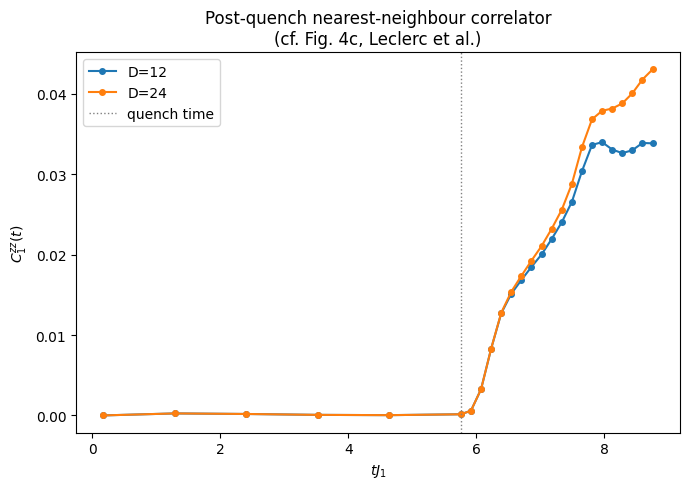

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for D, (t_ns, C1) in quench_results.items():
    tJ1 = t_ns * J1 / 1000.0  # ns -> us, times J1 (rad/us) -> dimensionless tJ1
    ax.plot(tJ1, C1, "-o", ms=4, label=f"D={D}")
ax.axvline(1000 * J1 / 1000.0, color="gray", ls=":", lw=1, label="quench time")
ax.set_xlabel(r"$t J_1$")
ax.set_ylabel(r"$C_1^{zz}(t)$")
ax.set_title("Post-quench nearest-neighbour correlator\n(cf. Fig. 4c, Leclerc et al.)")
ax.legend()
plt.tight_layout()
plt.savefig("phase2b_quench.png", dpi=140)
plt.show()


## 3. Interpretation & the bond-dimension diagnostic

Compare the two curves above:

* **If they overlap**, the emulation is converged at this evolution
  time / system size — trustworthy.
* **If they diverge** (typically at longer `tJ1`), that's exactly the
  MPS-convergence breakdown documented in Ext. Dat. Fig. 6 of Leclerc et
  al. and analysed in depth in Vovrosh et al. (arXiv:2511.19340,
  arXiv:2511.20388): entanglement grows with time after a quench, the
  bond dimension needed to represent the state grows with it, and
  eventually classical MPS emulation becomes intractable while the QPU
  keeps running at (roughly) constant cost.

For a **well-motivated Phase 2b deliverable**, report:
1. This plot, with an explicit statement of *at what `tJ1` the two bond
   dimensions start to disagree* (a simple relative-error threshold like
   Eq. B1 of the paper's SI works well).
2. A short physical interpretation: does the correlator relax toward a
   value consistent with a thermal ensemble at some effective
   temperature (Eq. 8 of the paper), or does it show persistent
   oscillations indicating a more coherent, non-thermal transient? At
   small `N` and short `t`, expect the latter — that's honest and worth
   saying explicitly rather than overclaiming thermalisation.

## Notes on scaling up

* This demo uses `N=25`, `t_hold ~ 3/J1`, and modest bond dimensions —
  chosen to run in well under a minute on a laptop CPU. The paper's
  Fig. 4 uses `N=256`, evolves to `tJ1 = O(10)`, and needs `D` up to 600
  on an H200 GPU (two weeks of wall-clock time!) to see the MPS
  description start to break down at long times — that's the genuine
  classical frontier this challenge gestures toward.
* To reach a QMC-thermal comparison (the paper's dashed lines in Fig. 4c),
  you'd need a stochastic-series-expansion sampler for `H_QPU`
  (Sandvik, Phys. Rev. E 68, 056701 (2003)) — out of scope for a
  hackathon, but a natural "if we had more time" callout in your writeup.
